In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["axes.unicode_minus"] = False
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 윈도우: 맑은 고딕
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df2=pd.read_csv('./data/통합_데이터.csv',encoding='utf-8-sig')

In [3]:
df2['영업_지속_한계_지수'] = df2["공시지가"]*df2["운영_영업_개월_평균"]
df2['지가_대비_지출_효율'] = df2["지출_총금액"]/df2["공시지가"]
df2['단위_유동인구당_소비액'] = df2["지출_총금액"]/df2["총_유동인구_수"]
df2['생존_연수_격차'] = df2['운영_영업_개월_평균']-df2["폐업_영업_개월_평균"]
df2['폐업_률'] = df2['폐업_점포_수']/df2['점포_수']

In [4]:
df2.head()

,기준_년분기_코드,자치구_코드,총_유동인구_수,월_평균_소득_금액,지출_총금액,운영_영업_개월_평균,폐업_영업_개월_평균,집객시설_수,점포_수,폐업_점포_수,공시지가,영업_지속_한계_지수,지가_대비_지출_효율,단위_유동인구당_소비액,생존_연수_격차,폐업_률
0,20244,11740,107151778,3292857,1.540000e+11,104,49,2063,22160,679,4136539,430200056,37229.190877,1437.213669,55,0.030641
1,20244,11710,120317054,3995905,3.710000e+11,110,50,2810,40391,1072,5971945,656913950,62123.813933,3083.519648,60,0.026541
2,20244,11680,144164615,4943841,2.790000e+12,102,49,4084,59857,1450,11922941,1216139982,234002.667630,19352.876571,53,0.024224
3,20244,11650,97166789,4912401,6.360000e+11,116,54,2779,39141,799,7218511,837347276,88106.813164,6545.446305,62,0.020413
4,20244,11620,126296711,2771927,1.190000e+11,102,50,2255,20120,667,3986627,406635954,29849.795328,942.225645,52,0.033151


In [5]:
def to_time_idx(yq):
    return (yq // 10) * 4 + (yq % 10)

base = to_time_idx(df2["기준_년분기_코드"].min())
df2["time_idx"] = df2['기준_년분기_코드'].apply(lambda x: to_time_idx(x) - base)

df2["gu_code"] = df2["자치구_코드"].astype("category").cat.codes



In [6]:
df2.head()

,기준_년분기_코드,자치구_코드,총_유동인구_수,월_평균_소득_금액,지출_총금액,운영_영업_개월_평균,폐업_영업_개월_평균,집객시설_수,점포_수,폐업_점포_수,공시지가,영업_지속_한계_지수,지가_대비_지출_효율,단위_유동인구당_소비액,생존_연수_격차,폐업_률,time_idx,gu_code
0,20244,11740,107151778,3292857,1.540000e+11,104,49,2063,22160,679,4136539,430200056,37229.190877,1437.213669,55,0.030641,15,24
1,20244,11710,120317054,3995905,3.710000e+11,110,50,2810,40391,1072,5971945,656913950,62123.813933,3083.519648,60,0.026541,15,23
2,20244,11680,144164615,4943841,2.790000e+12,102,49,4084,59857,1450,11922941,1216139982,234002.667630,19352.876571,53,0.024224,15,22
3,20244,11650,97166789,4912401,6.360000e+11,116,54,2779,39141,799,7218511,837347276,88106.813164,6545.446305,62,0.020413,15,21
4,20244,11620,126296711,2771927,1.190000e+11,102,50,2255,20120,667,3986627,406635954,29849.795328,942.225645,52,0.033151,15,20


In [7]:
df2.tail()

,기준_년분기_코드,자치구_코드,총_유동인구_수,월_평균_소득_금액,지출_총금액,운영_영업_개월_평균,폐업_영업_개월_평균,집객시설_수,점포_수,폐업_점포_수,공시지가,영업_지속_한계_지수,지가_대비_지출_효율,단위_유동인구당_소비액,생존_연수_격차,폐업_률,time_idx,gu_code
395,20211,11215,95233549,3192971,6.542633e+10,90,48,1602,18379,507,4164453,374800770,15710.665002,687.009218,42,0.027586,0,4
396,20211,11200,76432709,3734499,6.442913e+10,92,50,1693,17996,475,4353738,400543896,14798.577912,842.952341,42,0.026395,0,3
397,20211,11170,65905116,3971498,2.280000e+11,100,53,1504,18053,519,6552879,655287900,34793.866940,3459.518985,47,0.028749,0,2
398,20211,11140,56500462,3513603,2.020000e+12,109,58,2071,38483,1053,9763913,1064266517,206884.268633,35751.920046,51,0.027363,0,1
399,20211,11110,64341967,3725859,2.900000e+11,116,58,2058,23181,587,5781443,670647388,50160.487615,4507.167150,58,0.025322,0,0


In [8]:
df2["year"] = df2["기준_년분기_코드"] // 10
df2["quarter"] = df2["기준_년분기_코드"] % 10

df2["q_sin"] = np.sin(2 * np.pi * df2["quarter"] / 4)
df2["q_cos"] = np.cos(2 * np.pi * df2["quarter"] / 4)

In [9]:
df2.head()

,기준_년분기_코드,자치구_코드,총_유동인구_수,월_평균_소득_금액,지출_총금액,운영_영업_개월_평균,폐업_영업_개월_평균,집객시설_수,점포_수,폐업_점포_수,...,지가_대비_지출_효율,단위_유동인구당_소비액,생존_연수_격차,폐업_률,time_idx,gu_code,year,quarter,q_sin,q_cos
0,20244,11740,107151778,3292857,1.540000e+11,104,49,2063,22160,679,...,37229.190877,1437.213669,55,0.030641,15,24,2024,4,-2.449294e-16,1.0
1,20244,11710,120317054,3995905,3.710000e+11,110,50,2810,40391,1072,...,62123.813933,3083.519648,60,0.026541,15,23,2024,4,-2.449294e-16,1.0
2,20244,11680,144164615,4943841,2.790000e+12,102,49,4084,59857,1450,...,234002.667630,19352.876571,53,0.024224,15,22,2024,4,-2.449294e-16,1.0
3,20244,11650,97166789,4912401,6.360000e+11,116,54,2779,39141,799,...,88106.813164,6545.446305,62,0.020413,15,21,2024,4,-2.449294e-16,1.0
4,20244,11620,126296711,2771927,1.190000e+11,102,50,2255,20120,667,...,29849.795328,942.225645,52,0.033151,15,20,2024,4,-2.449294e-16,1.0


In [10]:
group_cols = ['gu_code']

df2 = df2.sort_values(group_cols + ["time_idx"])

target = "폐업_률"

for l in [1, 2, 4]:
    df2[f"lag_{l}"] = (
        df2.groupby(group_cols)[target]
          .shift(l)
    )

In [11]:
df2["roll_mean_4"] = (
    df2.groupby(group_cols)[target]
      .shift(1)
      .rolling(4)
      .mean()
)

df2["roll_std_4"] = (
    df2.groupby(group_cols)[target]
      .shift(1)
      .rolling(4)
      .std()
)


In [12]:
features = [
    "time_idx",
    "quarter", "q_sin", "q_cos",
    "lag_1", "lag_2", "lag_4",
    "roll_mean_4", "roll_std_4",
    'gu_code'
]

train_df2 = df2.dropna().reset_index(drop=True)

X = train_df2[features]
y = train_df2[target]

In [13]:
df2.head()

,기준_년분기_코드,자치구_코드,총_유동인구_수,월_평균_소득_금액,지출_총금액,운영_영업_개월_평균,폐업_영업_개월_평균,집객시설_수,점포_수,폐업_점포_수,...,gu_code,year,quarter,q_sin,q_cos,lag_1,lag_2,lag_4,roll_mean_4,roll_std_4
399,20211,11110,64341967,3725859,2.900000e+11,116,58,2058,23181,587,...,0,2021,1,1.000000e+00,6.123234e-17,NaN,NaN,NaN,NaN,NaN
374,20212,11110,66739796,3725859,3.140000e+11,117,58,2058,23216,577,...,0,2021,2,1.224647e-16,-1.000000e+00,0.025322,NaN,NaN,NaN,NaN
349,20213,11110,63583792,3725859,3.150000e+11,119,59,2058,23161,556,...,0,2021,3,-1.000000e+00,-1.836970e-16,0.024854,0.025322,NaN,NaN,NaN
324,20214,11110,66974979,3725859,3.450000e+11,119,59,2058,23283,497,...,0,2021,4,-2.449294e-16,1.000000e+00,0.024006,0.024854,NaN,NaN,NaN
299,20221,11110,64579681,3725859,3.120000e+11,120,59,2058,23291,488,...,0,2022,1,1.000000e+00,6.123234e-17,0.021346,0.024006,0.025322,0.023882,0.001776


In [14]:
import xgboost as xgb

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [15]:

unique_times = np.sort(train_df2["time_idx"].unique())
val_size = 4  # 검증 구간 (분기)
splits = []

max_folds = (len(unique_times) // val_size) - 1
n_splits = min(3, max_folds)

for i in range(n_splits):
    train_end = unique_times[-(val_size * (n_splits - i + 1))]
    val_start = train_end + 1
    val_end = train_end + val_size

    train_idx = train_df2[train_df2["time_idx"] <= train_end].index
    val_idx = train_df2[
        (train_df2["time_idx"] >= val_start) &
        (train_df2["time_idx"] <= val_end)
    ].index

    splits.append((train_idx, val_idx))


# ===============================
# 5. 학습 / 검증
# ===============================
preds, trues = [], []

for train_idx, val_idx in splits:
    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
    y_train, y_val = y.loc[train_idx], y.loc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    preds.extend(model.predict(X_val))
    trues.extend(y_val)

In [16]:
mae = mean_absolute_error(trues, preds)
print(f"MAE: {mae:.3f}")

MAE: 0.005


In [17]:
def make_future_features(df,model,features,steps=1):
    future = df.copy()

    for _ in range(steps):
        last = future.iloc[-1]

        next_time_idx = last["time_idx"] + 1
        next_quarter = 1 if last["quarter"] == 4 else last["quarter"] + 1
        next_year = last["year"] + 1 if next_quarter == 1 else last["year"]

        new_row = {
            "time_idx": next_time_idx,
            "year": next_year,
            "quarter": next_quarter,
            "q_sin": np.sin(2 * np.pi * next_quarter / 4),
            "q_cos": np.cos(2 * np.pi * next_quarter / 4),
            "lag_1": last[target],
            "lag_2": future.iloc[-2][target],
            "lag_4": future.iloc[-4][target],
            "roll_mean_4": future[target].tail(4).mean(),
            "roll_std_4": future[target].tail(4).std(),
            "gu_code": last["gu_code"],

            target: np.nan
        }

        future = pd.concat([future, pd.DataFrame([new_row])], ignore_index=True)

    return future


In [18]:
future_df = make_future_features(train_df2, model, features, steps=1)
print("다음 분기 예측값:", future_df.iloc[-1][target])

다음 분기 예측값: nan


- 위 는 모델만 만든거라 예측값 없는 것이 맞음

In [19]:
def recursive_forecast(df_hist, model, features, target, steps=4):
    future = df_hist.copy().reset_index(drop=True)
    preds = []

    for _ in range(steps):
        last = future.iloc[-1]

        next_time_idx = int(last["time_idx"] + 1)
        next_quarter = 1 if int(last["quarter"]) == 4 else int(last["quarter"]) + 1
        next_year = int(last["year"]) + 1 if next_quarter == 1 else int(last["year"])

        lag_1 = future.iloc[-1][target]
        lag_2 = future.iloc[-2][target] if len(future) >= 2 else np.nan
        lag_4 = future.iloc[-4][target] if len(future) >= 4 else np.nan
        roll_mean_4 = future[target].tail(4).mean()
        roll_std_4  = future[target].tail(4).std()

        X_next = pd.DataFrame([{
            "time_idx": next_time_idx,
            "year": next_year,
            "quarter": next_quarter,
            "q_sin": np.sin(2 * np.pi * next_quarter / 4),
            "q_cos": np.cos(2 * np.pi * next_quarter / 4),
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_4": lag_4,
            "roll_mean_4": roll_mean_4,
            "roll_std_4": roll_std_4,
            "gu_code": last["gu_code"],
        }])[features]

        y_hat = float(model.predict(X_next)[0])
        preds.append(y_hat)

        new_row = X_next.iloc[0].to_dict()
        new_row[target] = y_hat
        future = pd.concat([future, pd.DataFrame([new_row])], ignore_index=True)

    return preds

In [20]:
df2.columns

Index(['기준_년분기_코드', '자치구_코드', '총_유동인구_수', '월_평균_소득_금액', '지출_총금액',
       '운영_영업_개월_평균', '폐업_영업_개월_평균', '집객시설_수', '점포_수', '폐업_점포_수', '공시지가',
       '영업_지속_한계_지수', '지가_대비_지출_효율', '단위_유동인구당_소비액', '생존_연수_격차', '폐업_률',
       'time_idx', 'gu_code', 'year', 'quarter', 'q_sin', 'q_cos', 'lag_1',
       'lag_2', 'lag_4', 'roll_mean_4', 'roll_std_4'],
      dtype='object')

In [21]:
gu = 11680

df2_gu = (
    df2[df2["자치구_코드"] == gu]
    .sort_values("time_idx")
    .copy()
)

In [22]:
last = df2_gu.iloc[-1]

next_time_idx = last["time_idx"] + 1
next_quarter = 1 if last["quarter"] == 4 else last["quarter"] + 1

X_next = pd.DataFrame([{
    "time_idx": next_time_idx,
    "quarter": next_quarter,
    "q_sin": np.sin(2 * np.pi * next_quarter / 4),
    "q_cos": np.cos(2 * np.pi * next_quarter / 4),
    "lag_1": last[target],
    "lag_2": df2_gu.iloc[-2][target],
    "lag_4": df2_gu.iloc[-4][target],
    "roll_mean_4": df2_gu[target].tail(4).mean(),
    "roll_std_4": df2_gu[target].tail(4).std(),
    "gu_code": last["gu_code"]
}])[features]

pred = model.predict(X_next)[0]


In [23]:
print(pred)

0.036169436


In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

# =========================
# 0) 유틸 함수들 (안전장치)
# =========================
def safe_iloc(series: pd.Series, k: int):
    """마지막 k번째 값. 길이 부족하면 NaN."""
    return series.iloc[-k] if len(series) >= k else np.nan

def safe_roll_mean(series: pd.Series, window: int = 4):
    tail = series.tail(window)
    return tail.mean() if len(tail) > 0 else np.nan

def safe_roll_std(series: pd.Series, window: int = 4):
    tail = series.tail(window)
    return tail.std() if len(tail) > 1 else np.nan  # std는 최소 2개 이상일 때

def get_time_features_from_quarter(q: int):
    """quarter(1~4) -> sin/cos"""
    q = int(q)
    return (
        np.sin(2 * np.pi * q / 4),
        np.cos(2 * np.pi * q / 4)
    )

def ensure_sorted(df: pd.DataFrame, col: str = "time_idx"):
    if col in df.columns:
        return df.sort_values(col).reset_index(drop=True)
    return df.reset_index(drop=True)

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b)) if len(a) else np.nan

# ============================================
# 1) Recursive forecast (완전 안전 버전)
#    - year/quarter NaN이어도 동작
#    - lag/rolling 길이 부족 방어
#    - year/quarter는 "가능하면 유지", 없으면 val에서 쓰거나, 마지막 유효값으로 보정
# ============================================
def recursive_forecast(df_hist: pd.DataFrame, model, features, target: str, steps: int):
    """
    df_hist: 최소 과거 4개 이상 권장. (lag_4, rolling_4 때문에)
    steps: 앞으로 몇 step 예측할지
    return: 예측 리스트 길이 steps
    """
    future = ensure_sorted(df_hist.copy(), "time_idx")

    preds = []
    for i in range(steps):
        last = future.iloc[-1]

        # 다음 time_idx는 항상 +1
        next_time_idx = int(last["time_idx"]) + 1

        # quarter/year가 있으면 last로부터 추정, 없거나 NaN이면 마지막 유효값으로 추정
        if ("quarter" in future.columns) and ("year" in future.columns):
            tmp = future.dropna(subset=["year", "quarter"])
            if len(tmp) == 0:
                # year/quarter 자체가 없거나 전부 NaN이면: features에 year/quarter가 없다고 가정하거나,
                # 여기서는 일단 1분기/가상의 year(0)로 둠 (features에 year/quarter가 포함이면 데이터가 있어야 함)
                last_year, last_q = 0, 4
            else:
                last_year = int(tmp.iloc[-1]["year"])
                last_q = int(tmp.iloc[-1]["quarter"])
        else:
            last_year, last_q = 0, 4

        next_quarter = 1 if last_q == 4 else last_q + 1
        next_year = last_year + 1 if next_quarter == 1 else last_year

        q_sin, q_cos = get_time_features_from_quarter(next_quarter)

        # lag/rolling (target 기준)
        s = future[target]
        lag_1 = safe_iloc(s, 1)
        lag_2 = safe_iloc(s, 2)
        lag_4 = safe_iloc(s, 4)
        roll_mean_4 = safe_roll_mean(s, 4)
        roll_std_4 = safe_roll_std(s, 4)

        # gu_code는 df_hist에 있다고 가정 (없으면 에러로 원인 노출)
        if "gu_code" not in future.columns or pd.isna(last.get("gu_code", np.nan)):
            raise ValueError("recursive_forecast: gu_code가 없거나 NaN입니다.")

        row = {
            "time_idx": next_time_idx,
            "q_sin": q_sin,
            "q_cos": q_cos,
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_4": lag_4,
            "roll_mean_4": roll_mean_4,
            "roll_std_4": roll_std_4,
            "gu_code": last["gu_code"],
        }

        # year/quarter가 feature에 포함되어 있으면 채워줌
        if "year" in features:
            row["year"] = next_year
        if "quarter" in features:
            row["quarter"] = next_quarter

        X_next = pd.DataFrame([row])[features]
        y_hat = float(model.predict(X_next)[0])

        preds.append(y_hat)

        # 다음 step을 위해 future에 예측값을 붙임(Recursive)
        new_row = {**row, target: y_hat}
        future = pd.concat([future, pd.DataFrame([new_row])], ignore_index=True)

    return preds

# =========================
# 2) 메인 CV 평가 코드
# =========================
val_size = 4
results = []

# train_df2, X, y, splits, features, target 가 이미 준비되어 있다고 가정
# (형준이 형님 코드 그대로의 변수명 사용)

for fold_i, (train_idx, val_idx) in enumerate(splits, start=1):
    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
    y_train, y_val = y.loc[train_idx], y.loc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)

    # fold의 train_end / val_start / val_end 계산 (기존 로직 유지 + 안전)
    unique_times = np.sort(train_df2["time_idx"].unique())
    n_splits = len(splits)

    # 기존 수식은 위험할 수 있어, 범위를 벗어나면 안전하게 보정
    idx = -(val_size * (n_splits - (fold_i - 1) + 1))
    if abs(idx) > len(unique_times):
        # fallback: 마지막에서 val_size*n 만큼 떨어진 지점
        idx = max(-len(unique_times), -val_size * (n_splits - fold_i + 2))
    train_end = int(unique_times[idx])

    val_start = train_end + 1
    val_end = train_end + val_size

    # fold 데이터(원본)
    df_train_fold = train_df2[train_df2.index.isin(train_idx)].copy()
    df_val_fold   = train_df2[train_df2.index.isin(val_idx)].copy()

    # ---- A) Recursive 4-step 평가 ----
    rec_preds_all, rec_trues_all = [], []

    # ---- B) 1-step 평가 (teacher forcing) ----
    one_preds_all, one_trues_all = [], []

    for g in df_val_fold["gu_code"].unique():
        hist = df_train_fold[df_train_fold["gu_code"] == g].copy()
        valg = df_val_fold[df_val_fold["gu_code"] == g].copy()

        hist = ensure_sorted(hist, "time_idx")
        valg = ensure_sorted(valg, "time_idx")

        # 최소 과거 부족하면 스킵
        if len(hist) < 4:
            continue

        # --- Recursive: train_end까지를 히스토리로 잡고 앞으로 val_size 예측 ---
        hist_upto = hist[hist["time_idx"] <= train_end].copy()
        hist_upto = ensure_sorted(hist_upto, "time_idx")
        if len(hist_upto) < 4:
            continue

        # val 구간의 정답 (혹시 val에 결측 있으면 길이 맞출 때 자동으로 최소치 사용)
        val_slice = valg[(valg["time_idx"] >= val_start) & (valg["time_idx"] <= val_end)].copy()
        if len(val_slice) == 0:
            continue

        rec_preds = recursive_forecast(
            df_hist=hist_upto,
            model=model,
            features=features,
            target=target,
            steps=val_size
        )
        rec_trues = val_slice[target].values.tolist()

        m = min(len(rec_preds), len(rec_trues))
        rec_preds_all.extend(rec_preds[:m])
        rec_trues_all.extend(rec_trues[:m])

        # --- 1-step: t 시점의 year/quarter는 "valg(실제)"에서 직접 가져오도록 수정 ---
        for t in range(val_start, val_end + 1):
            # 해당 시점이 val에 없으면 skip
            if not (valg["time_idx"] == t).any():
                continue

            # t 예측을 위해 t-1까지의 실제를 포함한 히스토리
            hist_t = pd.concat([hist_upto, valg[valg["time_idx"] < t]], ignore_index=True)
            hist_t = ensure_sorted(hist_t, "time_idx")
            if len(hist_t) < 4:
                continue

            row_t = valg.loc[valg["time_idx"] == t].iloc[0]

            # ✅ year/quarter는 row_t에서 가져오기 (NaN이면 마지막 유효값으로 보정)
            year_t = row_t.get("year", np.nan)
            quarter_t = row_t.get("quarter", np.nan)

            if (("year" in features) or ("quarter" in features)):
                if pd.isna(year_t) or pd.isna(quarter_t):
                    tmp = hist_t.dropna(subset=["year", "quarter"])
                    if len(tmp) == 0:
                        raise ValueError(f"fold {fold_i}, gu {g}, t={t}: year/quarter가 전부 NaN입니다.")
                    year_t = int(tmp.iloc[-1]["year"])
                    quarter_t = int(tmp.iloc[-1]["quarter"])
                else:
                    year_t = int(year_t)
                    quarter_t = int(quarter_t)

            # q_sin/q_cos는 quarter 기준
            q_sin, q_cos = get_time_features_from_quarter(quarter_t)

            # lag/rolling은 hist_t의 target 기준 (실제값 기반 teacher forcing)
            s = hist_t[target]
            lag_1 = safe_iloc(s, 1)
            lag_2 = safe_iloc(s, 2)
            lag_4 = safe_iloc(s, 4)
            roll_mean_4 = safe_roll_mean(s, 4)
            roll_std_4 = safe_roll_std(s, 4)

            row = {
                "time_idx": int(t),
                "q_sin": q_sin,
                "q_cos": q_cos,
                "lag_1": lag_1,
                "lag_2": lag_2,
                "lag_4": lag_4,
                "roll_mean_4": roll_mean_4,
                "roll_std_4": roll_std_4,
                "gu_code": g
            }
            if "year" in features:
                row["year"] = year_t
            if "quarter" in features:
                row["quarter"] = quarter_t

            X_next = pd.DataFrame([row])[features]
            y_hat = float(model.predict(X_next)[0])
            y_true = float(row_t[target])

            one_preds_all.append(y_hat)
            one_trues_all.append(y_true)

    fold_result = {
        "fold": fold_i,
        "recursive_RMSE": rmse(rec_trues_all, rec_preds_all),
        "recursive_MAE": mean_absolute_error(rec_trues_all, rec_preds_all) if len(rec_trues_all) else np.nan,
        "one_step_RMSE": rmse(one_trues_all, one_preds_all),
        "one_step_MAE": mean_absolute_error(one_trues_all, one_preds_all) if len(one_trues_all) else np.nan,
        "n_recursive": len(rec_trues_all),
        "n_one_step": len(one_trues_all),
        "train_end": train_end,
        "val_start": val_start,
        "val_end": val_end
    }
    results.append(fold_result)

results_df = pd.DataFrame(results)
print(results_df)
print("\nAVG:")
print(results_df[["recursive_RMSE","recursive_MAE","one_step_RMSE","one_step_MAE"]].mean())


   fold  recursive_RMSE  recursive_MAE  one_step_RMSE  one_step_MAE  \
0     1             NaN            NaN            NaN           NaN   
1     2        0.004206       0.003214       0.004725       0.00377   

   n_recursive  n_one_step  train_end  val_start  val_end  
0            0           0          4          5        8  
1          100         100          8          9       12  

AVG:
recursive_RMSE    0.004206
recursive_MAE     0.003214
one_step_RMSE     0.004725
one_step_MAE      0.003770
dtype: float64


- 그런데 fold 1에서는:

train 구간이 time_idx ≤ 4

즉, gu별로 유효한 lag_4를 만들 수 있는 데이터가 거의 없음

In [25]:
def recursive_forecast(df_hist, model, features, target, steps=4):
    future = df_hist.copy().reset_index(drop=True)
    preds = []

    for _ in range(steps):
        last = future.iloc[-1]

        # 다음 시점 계산
        next_time_idx = int(last["time_idx"]) + 1
        next_quarter = 1 if int(last["quarter"]) == 4 else int(last["quarter"]) + 1
        next_year = int(last["year"]) + 1 if next_quarter == 1 else int(last["year"])

        # lag / rolling (recursive 핵심)
        lag_1 = future.iloc[-1][target]
        lag_2 = future.iloc[-2][target] if len(future) >= 2 else np.nan
        lag_4 = future.iloc[-4][target] if len(future) >= 4 else np.nan
        roll_mean_4 = future[target].tail(4).mean()
        roll_std_4  = future[target].tail(4).std()

        # 모델 입력
        X_next = pd.DataFrame([{
            "time_idx": next_time_idx,
            "year": next_year,
            "quarter": next_quarter,
            "q_sin": np.sin(2 * np.pi * next_quarter / 4),
            "q_cos": np.cos(2 * np.pi * next_quarter / 4),
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_4": lag_4,
            "roll_mean_4": roll_mean_4,
            "roll_std_4": roll_std_4,
            "gu_code": last["gu_code"],
        }])[features]

        y_hat = float(model.predict(X_next)[0])
        preds.append(y_hat)

        # ⭐️ 여기 중요: "완전한 다음 시점 row"를 직접 만든다
        new_row = {
            "time_idx": next_time_idx,
            "year": next_year,
            "quarter": next_quarter,
            "q_sin": np.sin(2 * np.pi * next_quarter / 4),
            "q_cos": np.cos(2 * np.pi * next_quarter / 4),
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_4": lag_4,
            "roll_mean_4": roll_mean_4,
            "roll_std_4": roll_std_4,
            "gu_code": last["gu_code"],
            target: y_hat
        }

        future = pd.concat([future, pd.DataFrame([new_row])], ignore_index=True)

    return preds

## 구별 RMSE 히트맵

In [26]:
val_size = 4

rows = []

for fold_i, (train_idx, val_idx) in enumerate(splits, start=1):
    # 모델 학습
    X_train, X_val = X.loc[train_idx], X.loc[val_idx]
    y_train, y_val = y.loc[train_idx], y.loc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
    model.fit(X_train, y_train)

    unique_times = np.sort(train_df2["time_idx"].unique())
    n_splits = len(splits)
    train_end = unique_times[-(val_size * (n_splits - (fold_i-1) + 1))]
    val_start = train_end + 1
    val_end = train_end + val_size

    df_train_fold = train_df2.loc[train_idx].copy()
    df_val_fold   = train_df2.loc[val_idx].copy()

    for g in df_val_fold["gu_code"].unique():
        hist = df_train_fold[df_train_fold["gu_code"] == g].sort_values("time_idx")
        valg = df_val_fold[df_val_fold["gu_code"] == g].sort_values("time_idx")

        hist_upto = hist[hist["time_idx"] <= train_end].copy()

        # 데이터 부족하면 기록만 남기고 스킵
        if len(hist_upto) < 4:
            rows.append({"fold": fold_i, "gu_code": g, "recursive_RMSE": np.nan, "one_step_RMSE": np.nan})
            continue

        # --- recursive ---
        rec_preds = recursive_forecast(hist_upto, model, features, target, steps=val_size)
        rec_trues = valg[(valg["time_idx"] >= val_start) & (valg["time_idx"] <= val_end)][target].values.tolist()
        m = min(len(rec_preds), len(rec_trues))
        rec_rmse = rmse(rec_trues[:m], rec_preds[:m])

        # --- one-step ---
        one_preds, one_trues = [], []
        for t in range(val_start, val_end + 1):
            hist_t = pd.concat([hist_upto, valg[valg["time_idx"] < t]], ignore_index=True)\
                        .sort_values("time_idx").reset_index(drop=True)
            if len(hist_t) < 4:
                continue

            last = hist_t.iloc[-1]
            next_quarter = 1 if int(last["quarter"]) == 4 else int(last["quarter"]) + 1
            next_year = int(last["year"]) + 1 if next_quarter == 1 else int(last["year"])

            X_next = pd.DataFrame([{
                "time_idx": t,
                "year": next_year,
                "quarter": next_quarter,
                "q_sin": np.sin(2 * np.pi * next_quarter / 4),
                "q_cos": np.cos(2 * np.pi * next_quarter / 4),
                "lag_1": hist_t.iloc[-1][target],
                "lag_2": hist_t.iloc[-2][target],
                "lag_4": hist_t.iloc[-4][target],
                "roll_mean_4": hist_t[target].tail(4).mean(),
                "roll_std_4": hist_t[target].tail(4).std(),
                "gu_code": g
            }])[features]

            one_preds.append(float(model.predict(X_next)[0]))
            # t가 val에 존재할 때만
            y_true_arr = valg[valg["time_idx"] == t][target].values
            if len(y_true_arr) == 0:
                continue
            one_trues.append(float(y_true_arr[0]))

        one_rmse = rmse(one_trues, one_preds)

        rows.append({"fold": fold_i, "gu_code": g, "recursive_RMSE": rec_rmse, "one_step_RMSE": one_rmse})

rmse_df = pd.DataFrame(rows)

# pivot: fold x gu_code
rec_map = rmse_df.pivot(index="fold", columns="gu_code", values="recursive_RMSE").sort_index(axis=1)
one_map = rmse_df.pivot(index="fold", columns="gu_code", values="one_step_RMSE").sort_index(axis=1)

rec_map, one_map

(gu_code        0         1         2         3         4         5         6   \
 fold                                                                            
 1             NaN       NaN       NaN       NaN       NaN       NaN       NaN   
 2        0.003674  0.004012  0.005795  0.007507  0.003613  0.006802  0.002329   
 
 gu_code        7         8         9   ...        15        16        17  \
 fold                                   ...                                 
 1             NaN       NaN       NaN  ...       NaN       NaN       NaN   
 2        0.003771  0.005079  0.004504  ...  0.004826  0.006066  0.006741   
 
 gu_code        18        19        20        21        22        23        24  
 fold                                                                           
 1             NaN       NaN       NaN       NaN       NaN       NaN       NaN  
 2        0.004794  0.004858  0.004635  0.006573  0.005306  0.005241  0.004414  
 
 [2 rows x 25 columns],
 gu_code  

In [27]:
gu_map = {
    0: "종로구",
    1: "중구",
    2: "용산구",
    3: "성동구",
    4: "광진구",
    5: "동대문구",
    6: "중랑구",
    7: "성북구",
    8: "강북구",
    9: "도봉구",
    10: "노원구",
    11: "은평구",
    12: "서대문구",
    13: "마포구",
    14: "양천구",
    15: "강서구",
    16: "구로구",
    17: "금천구",
    18: "영등포구",
    19: "동작구",
    20: "관악구",
    21: "서초구",
    22: "강남구",
    23: "송파구",
    24: "강동구",
}

In [28]:
gu_score = pd.DataFrame({
    "one_mean": one_map.mean(axis=0, skipna=True),
    "rmse_mean": rec_map.mean(axis=0, skipna=True),
    "rmse_std": rec_map.std(axis=0, skipna=True),
    "delta_mean": (rec_map - one_map).mean(axis=0, skipna=True),
})

gu_score_named = gu_score.copy()

gu_score_named.index = gu_score_named.index.map(
    lambda x: gu_map.get(int(x), str(x))
)

gu_score_named

,one_mean,rmse_mean,rmse_std,delta_mean
gu_code,,,,
종로구,0.002899,0.003674,NaN,0.000775
중구,0.003001,0.004012,NaN,0.001011
용산구,0.004061,0.005795,NaN,0.001733
성동구,0.006596,0.007507,NaN,0.000910
광진구,0.003620,0.003613,NaN,-0.000007
동대문구,0.006787,0.006802,NaN,0.000015
중랑구,0.001915,0.002329,NaN,0.000414
성북구,0.004388,0.003771,NaN,-0.000617
강북구,0.004700,0.005079,NaN,0.000379


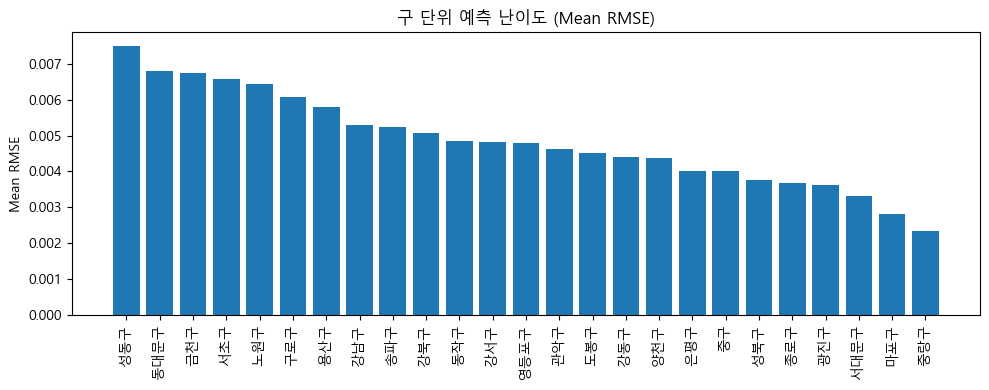

In [29]:
labels = [gu_map.get(code, str(code)) for code in gu_score.index]


# ======================================================
# 4. Mean RMSE 기준으로 정렬
# ======================================================
order = gu_score["rmse_mean"].sort_values(ascending=False).index
labels_sorted = [gu_map.get(code, str(code)) for code in order]
values_sorted = gu_score.loc[order, "rmse_mean"]


# ======================================================
# 5. 시각화
# ======================================================
plt.figure(figsize=(10, 4))
plt.bar(range(len(values_sorted)), values_sorted.values)
plt.xticks(range(len(values_sorted)), labels_sorted, rotation=90)
plt.ylabel("Mean RMSE")
plt.title("구 단위 예측 난이도 (Mean RMSE)")
plt.tight_layout()
plt.show()


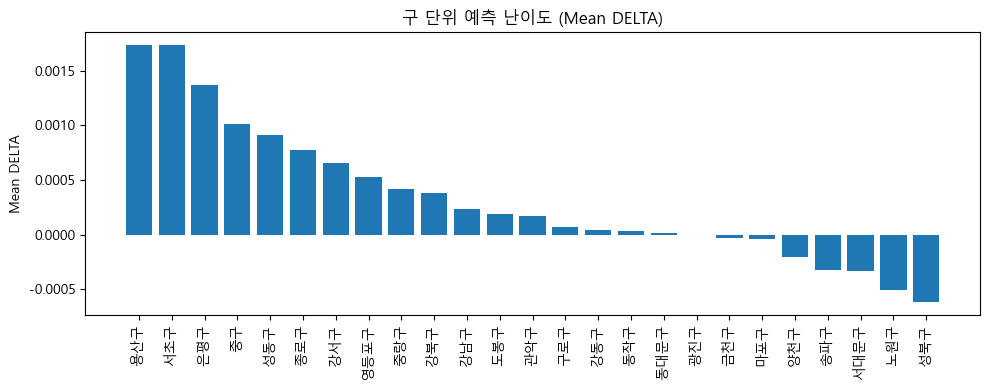

In [30]:
labels = [gu_map.get(code, str(code)) for code in gu_score.index]


# ======================================================
# 4. Mean RMSE 기준으로 정렬
# ======================================================
order = gu_score["delta_mean"].sort_values(ascending=False).index
labels_sorted = [gu_map.get(code, str(code)) for code in order]
values_sorted = gu_score.loc[order, "delta_mean"]


# ======================================================
# 5. 시각화
# ======================================================
plt.figure(figsize=(10, 4))
plt.bar(range(len(values_sorted)), values_sorted.values)
plt.xticks(range(len(values_sorted)), labels_sorted, rotation=90)
plt.ylabel("Mean DELTA")
plt.title("구 단위 예측 난이도 (Mean DELTA)")
plt.tight_layout()
plt.show()

- delta_mean = mean( recursive_RMSE − one_step_RMSE )

## 4개 분기 예측값

In [31]:

def recursive_forecast_with_future(df_hist, model, features, target, steps=4):
    future = df_hist.copy().reset_index(drop=True)
    preds = []
    future_rows = []

    for h in range(1, steps + 1):
        last = future.iloc[-1]

        next_time_idx = int(last["time_idx"]) + 1
        next_quarter = 1 if int(last["quarter"]) == 4 else int(last["quarter"]) + 1
        next_year = int(last["year"]) + 1 if next_quarter == 1 else int(last["year"])

        lag_1 = future.iloc[-1][target]
        lag_2 = future.iloc[-2][target] if len(future) >= 2 else np.nan
        lag_4 = future.iloc[-4][target] if len(future) >= 4 else np.nan
        roll_mean_4 = future[target].tail(4).mean()
        roll_std_4  = future[target].tail(4).std()

        # ✅ '전체 row' (메타 포함) 먼저 만든다
        next_row_full = {
            "time_idx": next_time_idx,
            "year": next_year,
            "quarter": next_quarter,
            "q_sin": np.sin(2 * np.pi * next_quarter / 4),
            "q_cos": np.cos(2 * np.pi * next_quarter / 4),
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_4": lag_4,
            "roll_mean_4": roll_mean_4,
            "roll_std_4": roll_std_4,
            "gu_code": last["gu_code"],
        }

        # ✅ 모델 입력은 features만
        X_next = pd.DataFrame([next_row_full])[features]

        y_hat = float(model.predict(X_next)[0])
        preds.append(y_hat)

        # ✅ future에 붙일 때는 메타 포함 full row를 사용
        next_row_full[target] = y_hat
        next_row_full["horizon"] = h

        future_rows.append(next_row_full)
        future = pd.concat([future, pd.DataFrame([next_row_full])], ignore_index=True)

    return preds, pd.DataFrame(future_rows)

In [32]:
import xgboost as xgb

final_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
final_model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [33]:
steps = 4
all_future = []

# 각 gu_code별 마지막 실제 관측값
last_actual = (
    train_df2
    .sort_values("time_idx")
    .groupby("gu_code")
    .tail(1)
    .loc[:, ["gu_code", "year", "quarter", "time_idx", target]]
    .rename(columns={target: "value"})
)

last_actual["horizon"] = 0
last_actual["type"] = "actual"


for g in sorted(train_df2["gu_code"].unique()):
    df_g = train_df2[train_df2["gu_code"] == g].sort_values("time_idx")

    # lag_4를 쓰므로 최소 4개 이상 필요 (롤링도 4개 필요)
    if len(df_g) < 4:
        continue

    preds, future_rows = recursive_forecast_with_future(
        df_hist=df_g,
        model=final_model,
        features=features,
        target=target,
        steps=steps
    )

    # 원하는 컬럼만 정리
    out = future_rows[["gu_code", "time_idx", "year", "quarter", "horizon", target]].copy()
    out = out.rename(columns={target: "pred"})
    all_future.append(out)

future_pred_df = pd.concat(all_future, ignore_index=True)
future_pred = future_pred_df.copy()

future_pred = future_pred.rename(columns={"pred": "value"})
future_pred["type"] = "pred"

final_result = pd.concat(
    [
        last_actual[["gu_code","year","quarter","horizon","value","type"]],
        future_pred[["gu_code","year","quarter","horizon","value","type"]],
    ],
    ignore_index=True
).sort_values(["gu_code","horizon"]).reset_index(drop=True)

final_wide = final_result.pivot_table(
    index="gu_code",
    columns="horizon",
    values="value",
    aggfunc="first"
).rename(columns={
    0: "t0_actual",
    1: "t+1",
    2: "t+2",
    3: "t+3",
    4: "t+4",
}).reset_index()

final_result["gu_name"] = final_result["gu_code"].map(
    lambda x: gu_map.get(int(x), str(x))
)

# 컬럼 순서 정리 (가독성)
final_result = final_result[
    ["gu_name", "year", "quarter", "value", "type"]
]

final_result.head(10)

,gu_name,year,quarter,value,type
0,종로구,2024,4,0.018944,actual
1,종로구,2025,1,0.024132,pred
2,종로구,2025,2,0.019863,pred
3,종로구,2025,3,0.021284,pred
4,종로구,2025,4,0.019660,pred
5,중구,2024,4,0.021220,actual
6,중구,2025,1,0.024610,pred
7,중구,2025,2,0.020125,pred
8,중구,2025,3,0.022051,pred
9,중구,2025,4,0.019474,pred


In [34]:
new=pd.read_csv('./data/2025_file.csv',encoding='utf-8-sig')

In [35]:
new.head()

,Unnamed: 0,gu_name,year,quarter,real
0,0,종로구,2025,1,0.026095
1,1,중구,2025,1,0.024582
2,2,용산구,2025,1,0.029784
3,3,성동구,2025,1,0.029848
4,4,광진구,2025,1,0.036626


In [36]:
new=new.drop(['Unnamed: 0'],axis=1)

In [37]:
new.head()

,gu_name,year,quarter,real
0,종로구,2025,1,0.026095
1,중구,2025,1,0.024582
2,용산구,2025,1,0.029784
3,성동구,2025,1,0.029848
4,광진구,2025,1,0.036626


In [38]:
df_add=pd.merge(final_result,new,on=['gu_name','year','quarter'],how='right')

In [39]:
df_add.head()

,gu_name,year,quarter,value,type,real
0,종로구,2025,1,0.024132,pred,0.026095
1,중구,2025,1,0.024610,pred,0.024582
2,용산구,2025,1,0.029894,pred,0.029784
3,성동구,2025,1,0.030538,pred,0.029848
4,광진구,2025,1,0.038911,pred,0.036626


In [40]:
df_add1=pd.merge(final_result,new,on=['gu_name','year','quarter'],how='outer')

In [41]:
df_add1.head()

,gu_name,year,quarter,value,type,real
0,강남구,2024,4,0.024224,actual,NaN
1,강남구,2025,1,0.033675,pred,0.029825
2,강남구,2025,2,0.028872,pred,0.024188
3,강남구,2025,3,0.028602,pred,0.026029
4,강남구,2025,4,0.025201,pred,NaN


In [42]:
df_add1['오차_값']=df_add1['real']-df_add1['value']

In [43]:
df_add1.head()

,gu_name,year,quarter,value,type,real,오차_값
0,강남구,2024,4,0.024224,actual,NaN,NaN
1,강남구,2025,1,0.033675,pred,0.029825,-0.003850
2,강남구,2025,2,0.028872,pred,0.024188,-0.004684
3,강남구,2025,3,0.028602,pred,0.026029,-0.002573
4,강남구,2025,4,0.025201,pred,NaN,NaN


In [44]:
df_add1

,gu_name,year,quarter,value,type,real,오차_값
0,강남구,2024,4,0.024224,actual,NaN,NaN
1,강남구,2025,1,0.033675,pred,0.029825,-0.003850
2,강남구,2025,2,0.028872,pred,0.024188,-0.004684
3,강남구,2025,3,0.028602,pred,0.026029,-0.002573
4,강남구,2025,4,0.025201,pred,NaN,NaN
...,...,...,...,...,...,...,...
120,중랑구,2024,4,0.030007,actual,NaN,NaN
121,중랑구,2025,1,0.037636,pred,0.038394,0.000758
122,중랑구,2025,2,0.032752,pred,0.032734,-0.000019
123,중랑구,2025,3,0.032471,pred,0.029118,-0.003353
